In [83]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time


In [84]:
rootfolder = '.'

Useful function for plot a 2D dictionary

In [85]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [86]:
def OMP(s, D, L, tau):
  M, N = D.shape
  r = s
  x_OMP = np.zeros(N) 
  omega = []

  while np.linalg.norm(r) > tau and np.count_nonzero(x_OMP) < L: #STOPPING CRITERIA:

      # SWEEP STEP: look for the column of D that matches at best noisySignal
      # compute the residual w.r.t. each column of D
      e = np.zeros(N)
      for j in range(N):
          e[j] = np.linalg.norm(r)**2 - (r @ D[:, j])**2

      # find the column of D that matches at best r
      jStar = np.argmin(e)

      # UPDATE the support set with the jStar coefficient
      omega.append(jStar)
      # update the coefficients by solving the least square problem min ||D_omega x - s ||


      Xw = np.linalg.inv(D[:, omega].T @ D[:, omega]) @ D[:, omega].T @ s

      x_OMP = np.zeros(N)
      x_OMP[omega] = Xw

      # update the residual
      r = s - D @ x_OMP
  
  return x_OMP


Load the image and rescale it in $[0,1]$

In [87]:
img = imread(f'{rootfolder}/data/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [88]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the PSNR of the noisy input

In [89]:
psnr_noisy = 10 * np.log10(1/np.mean((noisy_img - img)**2))


Text(0.5, 1.0, 'Noisy image, PSNR = 22.14')

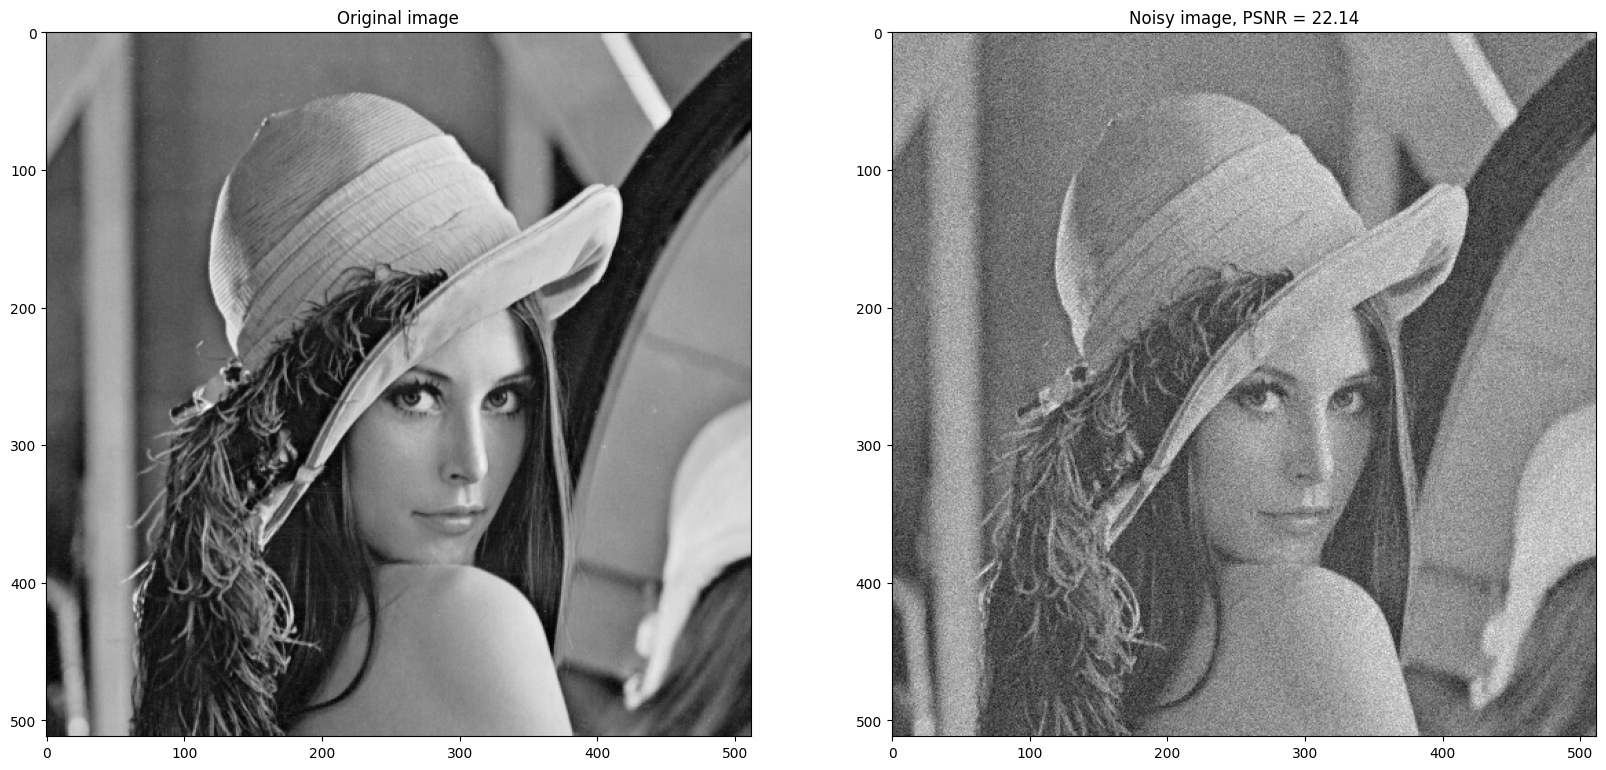

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Load and display the dictionary learned from patches

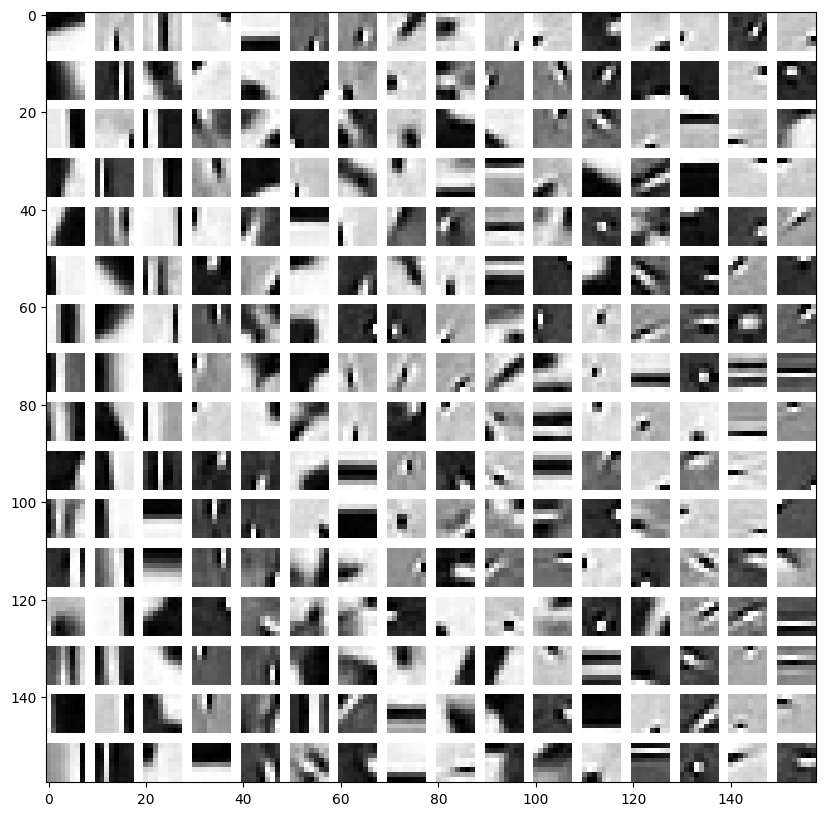

In [91]:
D = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

# display the learned basis
D_img = get_dictionary_img(D)
plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')

Denoising
---------


In [92]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# set the threshold
tau = 1.15 * p * sigma_noise

# define the step (=p for non overlapping paches)
STEP = 2 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise

In [93]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # store and subtract the mean
        mean = np.mean(s)
        s = s - mean

        # perform the sparse coding
        x = OMP(s.reshape(-1), D, 4, tau)

        # perform the reconstruction
        s_hat = D @ x


        # add back the mean
        s_hat += mean 

        # put the denoised patch into the estimated image using uniform weights
        img_hat[i:i+p, j:j+p] += s_hat.reshape((p,p))

        # store the weight of the current patch in the weight matrix
        weights[i:i+p, j:j+p] += 1

Normalize the estimated image with the computed weights

In [94]:
img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 31.98')

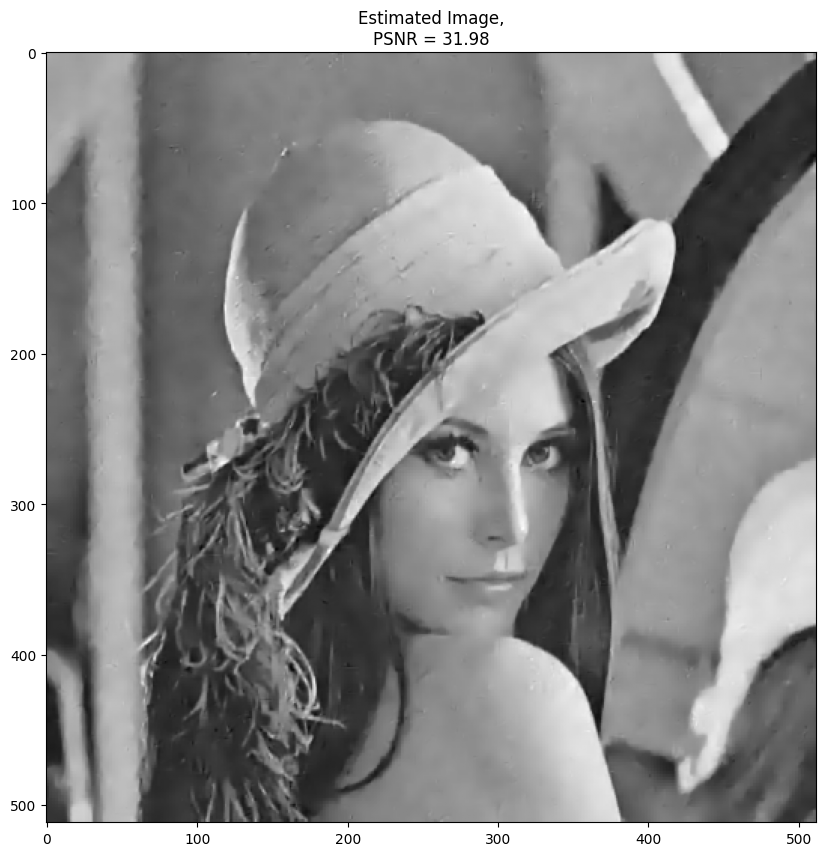

In [95]:
psnr_hat = 10 * np.log10(1/np.mean((img - img_hat)**2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')


Tikhonov Regularization Denoising
---------
Apply Tikhonov regularization and compare to OMP Denosing

In [98]:
# initialize the estimated image for Tikhonov
img_hat_tic = np.zeros_like(img)

# initialize the weight matrix
weights_tic = np.zeros_like(img)

# set the regularization parameter
lmbda = 1

# precompute the Tikhonov matrix: x_tic = (D.T * D + lambda * I)^-1 * D.T * s
M, N = D.shape
H_tic = np.linalg.inv(D.T @ D + lmbda * np.identity(N)) @ D.T 

In [99]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extract the patch with the top left corner at pixel (i, j)
        s = noisy_img[i:i+p, j:j+p]


        # store and subtract the mean
        mean = np.mean(s)
        s = s - mean
        # solve using Tikhonov closed form#
        x_tic = H_tic @ s.reshape(-1)

        # perform the reconstruction
        s_hat = D @ x_tic
        
        w = 1

        # add back the mean
        s_hat += mean 

        # put the denoised patch into the estimated image using uniform weights
        img_hat_tic[i:i+p, j:j+p] += s_hat.reshape((p,p))

        # store the weight of the current patch in the weight matrix
        weights_tic[i:i+p, j:j+p] += w

Normalize the estimated image and evaluate the PSNR

Text(0.5, 1.0, 'Estimated Image (Tikhonov),\nPSNR = 25.89')

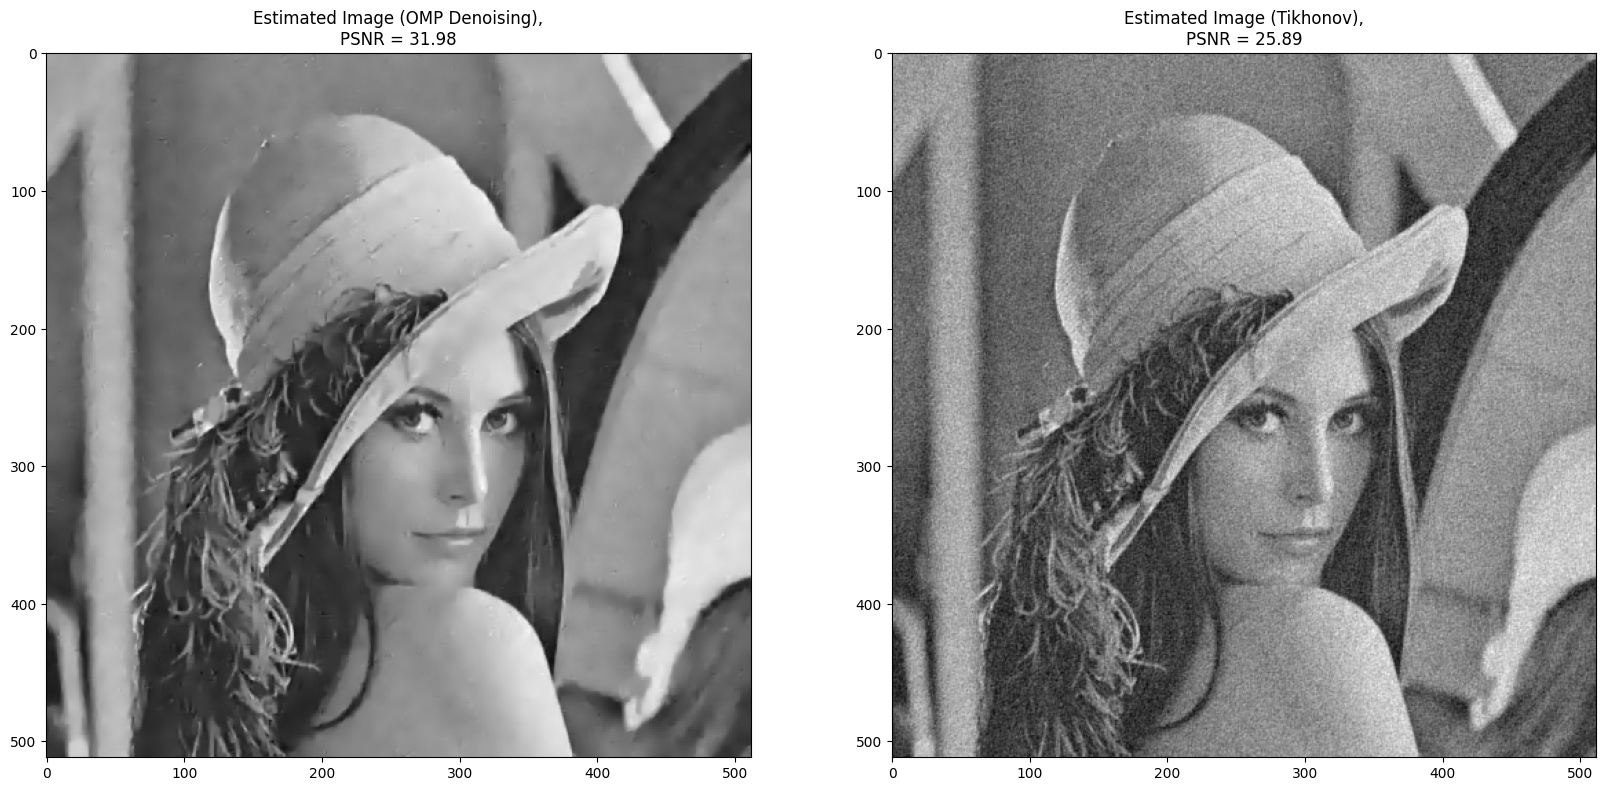

In [100]:
# normalize the estimated image with the computed weights
img_hat_tic = img_hat_tic/weights_tic

# compute the PSNR of the Tikhonov estimated image
psnr_hat_tic = 10 * np.log10(1/np.mean((img -img_hat_tic)**2))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'Estimated Image (OMP Denoising),\nPSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_tic, cmap='gray')
ax[1].set_title(f'Estimated Image (Tikhonov),\nPSNR = {psnr_hat_tic:.2f}')